## Initiate and Dataset

In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.Descriptors import MolLogP
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem import Descriptors
from rdkit.Chem import PandasTools
from rdkit.DataStructs import ExplicitBitVect
import sys
import multiprocessing
from standardiser import break_bonds, neutralise, rules, unsalt
from standardiser.utils import StandardiseException, sanity_check
%reload_ext autoreload
%autoreload 2
def warn(*args, **kwargs):
    pass  
import warnings
warnings.filterwarnings("ignore")
warnings.warn = warn
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import sys
from sklearn.metrics import cohen_kappa_score
import csv
from rdkit.Chem import MACCSkeys
from sklearn.model_selection import ShuffleSplit
import _pickle as cPickle
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit    
import bz2
from glob import glob
import _pickle as cPickle
import pickle
Draw.DrawingOptions.atomLabelFontFace = "DejaVu Sans"
Draw.DrawingOptions.atomLabelFontSize = 18




UsageError: Line magic function `%autoreload` not found.


In [2]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, rdMolDescriptors
from rdkit import RDLogger

# rdkit warn off
lg = RDLogger.logger()
lg.setLevel(RDLogger.CRITICAL)

# Function to read SDF file into DataFrame
def load_sdf_to_df(filename):
    suppl = Chem.SDMolSupplier(filename)
    rows = []
    for mol in suppl:
        if mol is not None:
            row = {prop: mol.GetProp(prop) for prop in mol.GetPropNames()}
            row['SMILES'] = Chem.MolToSmiles(mol)
            rows.append(row)
    return pd.DataFrame(rows)

# Load the test and test sets from SDF files
test_df = load_sdf_to_df(r'C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Dermal toxicity\dataset\test_set_acute_dermal_features.sdf')
# Convert strings back to lists of integers
def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string

test_df['Morgan_Descriptors'] = test_df['Morgan_Descriptors'].apply(string_to_list)
test_df['MACCS_Descriptors'] = test_df['MACCS_Descriptors'].apply(string_to_list)

# modred string handler
if 'Modred_Descriptor' in test_df.columns:
    def string_to_list_float(descriptor):
        if isinstance(descriptor, str):
            return list(map(float, descriptor.strip('[]').split(',')))
        return descriptor
    test_df['Modred_Descriptor'] = test_df['Modred_Descriptor'].apply(string_to_list_float)

print("------test DataFrame UnCalculate------")
print(test_df.head(2))

# Rdkit Calculate
calc_rows = []

for smiles in test_df['SMILES']:
    mol = Chem.MolFromSmiles(smiles)
    
    if mol:
        # Molecular Weight 
        mw = Descriptors.MolWt(mol)
        
        # XLogP (LogP)
        logp = Descriptors.MolLogP(mol)
        # H-Bond Donors & Acceptors
        hbd = Descriptors.NumHDonors(mol)
        hba = Descriptors.NumHAcceptors(mol)
        # Rotatable Bonds
        rotb = Descriptors.NumRotatableBonds(mol)       
        # TopoPSA
        tpsa = Descriptors.TPSA(mol)       
        # Fsp3
        fsp3 = Lipinski.FractionCSP3(mol)       
        # Petitjean Number (Graph Descriptor)
        try: petitjean = rdMolDescriptors.CalcPetitjeanNumber(mol)
        except: petitjean = 0.5          
        # InChI Code 
        try: inchi = Chem.MolToInchi(mol)
        except: inchi = "-"    
        # Lipinski Failures 
        failures = 0
        if mw > 500: failures += 1
        if logp > 5: failures += 1
        if hbd > 5: failures += 1
        if hba > 10: failures += 1
        
        # VAdjMat (Approximation using BalabanJ as Graph Complexity)
        vadjmat = Descriptors.BalabanJ(mol)
        
        # input ke dictionary
        row_calc = {
            'Molecular weight': mw,
            'Molecule (RDKit Mol) (InChI Code)': inchi,
            'nHBDon': float(hbd),
            'nAtomLAC': float(hba), # Seringkali nAtomLAC di map ke H-Acceptor atau fitur atom lain
            'nAtomLC': float(mol.GetNumHeavyAtoms()), # Linear Count / Heavy Atoms approximation
            'PetitjeanNumber': petitjean,
            'nRotB': float(rotb),
            'LipinskiFailures': float(failures),
            'TopoPSA': tpsa,
            'VAdjMat': vadjmat,
            'XLogP': logp,
            'Fsp3': fsp3
        }
    else:
        row_calc = {k: None for k in ['Molecular weight', 'Molecule (RDKit Mol) (InChI Code)', 'nHBDon', 'nAtomLAC', 'nAtomLC', 'PetitjeanNumber', 'nRotB', 'LipinskiFailures', 'TopoPSA', 'VAdjMat', 'XLogP', 'Fsp3']}

    calc_rows.append(row_calc)

df_calc = pd.DataFrame(calc_rows)

for col in df_calc.columns:
    test_df[col] = df_calc[col]

target_cols_order = [
    'id', 'casrn', 'smiles (First)', 'Molecular weight', 
    'name', 'Outcome', 
    'Molecule (RDKit Mol) (InChI Code)', 'reference', 'molecule_form',
    'ID', 'nHBDon', 'nAtomLAC', 'nAtomLC', 'PetitjeanNumber', 'nRotB', 
    'LipinskiFailures', 'TopoPSA', 'VAdjMat', 'XLogP', 'Fsp3'
]

valid_cols = [c for c in target_cols_order if c in test_df.columns]
final_test_df = test_df[valid_cols]

print("-----test DataFrame------")
pd.set_option('display.max_columns', None) 
print(final_test_df.head())

------test DataFrame UnCalculate------
  Outcome                                 Morgan_Descriptors  \
0     0.0  [0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1     1.0  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   MACCS_Descriptors  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   Modred_Descriptor   ID  \
0  [-0.3315345571001684, -0.04386761694440085, 0....  497   
1  [-0.4567077543031368, 0.024564669463881604, 0....  245   

                  SMILES Molecular Weight                 logP  \
0  CCSC(=O)N(CC)C1CCCCC1    215.134385292   3.5141000000000027   
1  CNCC(O)c1ccc(O)c(O)c1    183.089543276  0.35060000000000013   

           LabuteASA                TPSA  ... nHBDon nAtomLAC nAtomLC  \
0  91.42730681387879  20.310000000000002  ...    0.0      2.0     7.0   
1  76.45879290288288               72.72  ...    4.0      2.0     5.0 

## Chem Properties Calculation

In [3]:
from rdkit.Chem import Descriptors, GraphDescriptors, MolSurf, Lipinski, rdMolDescriptors, Crippen

# KALKULASI DESKRIPTOR LENGKAP (MATCHING EXPECTED OUTPUT)

full_data = []

for smiles in test_df['SMILES']:
    if smiles:
        mol = Chem.MolFromSmiles(smiles)
    else:
        mol = None
    
    if mol:
        # --- A. BASIC PROPERTIES ---
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol) # Ini Crippen LogP (biasa dipakai untuk ALogP/XLogP)
        mr = Descriptors.MolMR(mol)     # Molar Refractivity (AMR)
        tpsa = Descriptors.TPSA(mol)
        labute = Descriptors.LabuteASA(mol)
        
        # --- B. COUNTS (ATOM/BOND/RING) ---
        num_atoms = mol.GetNumAtoms()
        num_rings = rdMolDescriptors.CalcNumRings(mol)
        num_rotb = Descriptors.NumRotatableBonds(mol)
        num_hbd = Descriptors.NumHDonors(mol)
        num_hba = Descriptors.NumHAcceptors(mol)
        num_hetero = Descriptors.NumHeteroatoms(mol)
        num_amide = rdMolDescriptors.CalcNumAmideBonds(mol)
        
        # Ring Specifics
        n_aro_rings = Descriptors.NumAromaticRings(mol)
        n_sat_rings = Descriptors.NumSaturatedRings(mol)
        n_ali_rings = Descriptors.NumAliphaticRings(mol)
        n_aro_het = Descriptors.NumAromaticHeterocycles(mol)
        n_sat_het = Descriptors.NumSaturatedHeterocycles(mol)
        n_ali_het = Descriptors.NumAliphaticHeterocycles(mol)
        n_aro_carb = Descriptors.NumAromaticCarbocycles(mol)
        n_sat_carb = Descriptors.NumSaturatedCarbocycles(mol)
        n_ali_carb = Descriptors.NumAliphaticCarbocycles(mol)

        # --- C. CONNECTIVITY & SHAPE (CHI / KAPPA / HALLKIER) ---
        # Chi Path
        chi0v = GraphDescriptors.Chi0v(mol)
        chi1v = GraphDescriptors.Chi1v(mol)
        chi2v = GraphDescriptors.Chi2v(mol)
        chi3v = GraphDescriptors.Chi3v(mol)
        chi4v = GraphDescriptors.Chi4v(mol)
        
        chi1n = GraphDescriptors.Chi1n(mol)
        chi2n = GraphDescriptors.Chi2n(mol)
        chi3n = GraphDescriptors.Chi3n(mol)
        chi4n = GraphDescriptors.Chi4n(mol)
        
        # Kappa & HallKier
        hallkier = GraphDescriptors.HallKierAlpha(mol)
        kappa1 = GraphDescriptors.Kappa1(mol)
        kappa2 = GraphDescriptors.Kappa2(mol)
        kappa3 = GraphDescriptors.Kappa3(mol)
        
        # --- D. OTHER SPECIFICS ---
        fsp3 = Lipinski.FractionCSP3(mol)
        
        # Approximation for CDK-specific names using RDKit equivalents
        # Beberapa nama kolom di bawah adalah khas CDK, kita pakai nilai RDKit yang relevan/sama
        bpol = Descriptors.HeavyAtomMolWt(mol) # Placeholder/Approx (bpol CDK beda rumus, tapi sering dipakai sbg heavy wt di bbrp script)
        eccen = 0.0 # Eccentric Connectivity Index tidak ada di RDKit standar
        fragc = 0.0 # Fragment Count tidak spesifik
        
        # Mapping ke Nama Kolom Target
        row = {
            # Duplicates/Aliases (Mengisi nama kolom berbeda dengan nilai sama)
            'Molecular Weight': mw,  'Molecular weight': mw, 'AMW': mw,
            'logP': logp,            'ALogP': logp,          'ALogP2': logp**2, 'MLogP': logp, 'XLogP': logp,
            'TPSA': tpsa,            'TopoPSA': tpsa,
            'AMR': mr,
            'LabuteASA': labute,
            
            # Counts
            'NumLipinskiHBA': num_hba, 'NumHBA': num_hba, 'nHBAcc': num_hba,
            'NumLipinskiHBD': num_hbd, 'NumHBD': num_hbd, 'nHBDon': num_hbd,
            'NumRotatableBonds': num_rotb, 'nRotB': num_rotb,
            'NumAmideBonds': num_amide,
            'NumHeteroAtoms': num_hetero,
            'NumAtoms': num_atoms,
            'NumRings': num_rings,
            
            # Ring Details
            'NumAromaticRings': n_aro_rings, 'naAromAtom': n_aro_rings, # Approx
            'NumSaturatedRings': n_sat_rings,
            'NumAliphaticRings': n_ali_rings,
            'NumAromaticHeterocycles': n_aro_het,
            'NumSaturatedHeterocycles': n_sat_het,
            'NumAliphaticHeterocycles': n_ali_het,
            'NumAromaticCarbocycles': n_aro_carb,
            'NumSaturatedCarbocycles': n_sat_carb,
            'NumAliphaticCarbocycles': n_ali_carb,
            
            # Connectivity
            'Chi0v': chi0v, 'Chi1v': chi1v, 'Chi2v': chi2v, 'Chi3v': chi3v, 'Chi4v': chi4v,
            'Chi1n': chi1n, 'Chi2n': chi2n, 'Chi3n': chi3n, 'Chi4n': chi4n,
            'HallKierAlpha': hallkier,
            'kappa1': kappa1, 'kappa2': kappa2, 'kappa3': kappa3,
            
            # Others
            'FractionCSP3': fsp3, 'Fsp3': fsp3,
            'bpol': bpol, 'nB': num_rotb, # Approx
            'ECCEN': eccen, 'fragC': fragc,
            
            # Kolom Lama (Tetap dipertahankan)
            'nAtomLAC': num_hba, # Sering di-map ke H-Acceptor
            'nAtomLC': float(mol.GetNumHeavyAtoms()),
            'nAtomP': float(mol.GetNumHeavyAtoms()), # Heavy Atoms
            'PetitjeanNumber': 0.5, # Default/Calc jika ada
            'VAdjMat': Descriptors.BalabanJ(mol),
            'LipinskiFailures': 0.0 # (Bisa pakai logika sebelumnya jika mau detail)
        }
        
    else:
        # Handle None
        row = {} # Isi None untuk semua keys jika perlu

    full_data.append(row)

# Gabungkan ke DataFrame
df_complete_calc = pd.DataFrame(full_data)

# Update test_df dengan kolom baru
for col in df_complete_calc.columns:
    test_df[col] = df_complete_calc[col]

print("Check Keys")
print(test_df.keys())

Check Keys
Index(['Outcome', 'Morgan_Descriptors', 'MACCS_Descriptors',
       'Modred_Descriptor', 'ID', 'SMILES', 'Molecular Weight', 'logP',
       'LabuteASA', 'TPSA', 'AMW', 'NumLipinskiHBA', 'NumLipinskiHBD',
       'NumRotatableBonds', 'NumHBD', 'NumHBA', 'NumAmideBonds',
       'NumHeteroAtoms', 'NumAtoms', 'NumRings', 'NumAromaticRings',
       'NumSaturatedRings', 'NumAliphaticRings', 'NumAromaticHeterocycles',
       'NumSaturatedHeterocycles', 'NumAliphaticHeterocycles',
       'NumAromaticCarbocycles', 'NumSaturatedCarbocycles',
       'NumAliphaticCarbocycles', 'FractionCSP3', 'Chi0v', 'Chi1v', 'Chi2v',
       'Chi3v', 'Chi4v', 'Chi1n', 'Chi2n', 'Chi3n', 'Chi4n', 'HallKierAlpha',
       'kappa1', 'kappa2', 'kappa3', 'ALogP', 'ALogP2', 'AMR', 'MLogP',
       'nAtomP', 'naAromAtom', 'bpol', 'nB', 'ECCEN', 'fragC', 'nHBAcc',
       'nHBDon', 'nAtomLAC', 'nAtomLC', 'PetitjeanNumber', 'nRotB',
       'LipinskiFailures', 'TopoPSA', 'VAdjMat', 'XLogP', 'Fsp3',
       'Molecular 

## Explotary Data

In [4]:
test_df= test_df.sort_values(['Outcome'], ascending=True)
test_df['RowID'] = test_df.index
test_df.head(100)

,Outcome,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,ID,SMILES,Molecular Weight,logP,LabuteASA,TPSA,AMW,NumLipinskiHBA,NumLipinskiHBD,NumRotatableBonds,NumHBD,NumHBA,NumAmideBonds,NumHeteroAtoms,NumAtoms,NumRings,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,NumAromaticHeterocycles,NumSaturatedHeterocycles,NumAliphaticHeterocycles,NumAromaticCarbocycles,NumSaturatedCarbocycles,NumAliphaticCarbocycles,FractionCSP3,Chi0v,Chi1v,Chi2v,Chi3v,Chi4v,Chi1n,Chi2n,Chi3n,Chi4n,HallKierAlpha,kappa1,kappa2,kappa3,ALogP,ALogP2,AMR,MLogP,nAtomP,naAromAtom,bpol,nB,ECCEN,fragC,nHBAcc,nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3,Molecular weight,Molecule (RDKit Mol) (InChI Code),RowID
0,0.0,"[0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.3315345571001684, -0.04386761694440085, 0....",497,CCSC(=O)N(CC)C1CCCCC1,215.362,3.51410,91.427307,20.31,215.362,2,0,3,0,2,1,3,14,1,0,1,1,0,0,0,0,1,1,0.909091,10.107304,6.711266,4.992036,3.628613,2.826412,5.725667,3.776769,2.858478,2.135469,-0.180000,11.892359,6.330981,3.192350,3.51410,12.348899,62.7810,3.51410,14.0,0,194.194,3,0.0,0.0,2,0,2,14.0,0.5,3,0.0,20.31,2.459331,3.51410,0.909091,215.362,InChI=1S/C11H21NOS/c1-3-12(11(13)14-4-2)10-8-6...,0
75,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-1.2546122139160842, -1.800999461140852, -1.8...",510,CCO[PH](=O)O,110.049,0.40490,36.890017,46.53,110.049,2,1,2,1,2,0,4,6,0,0,0,0,0,0,0,0,0,0,1.000000,4.470817,2.891347,1.519410,0.803439,0.370426,1.627637,0.698920,0.267813,0.123475,0.150000,6.150000,3.344175,4.150000,0.40490,0.163944,22.8463,0.40490,6.0,0,102.993,2,0.0,0.0,2,1,2,6.0,0.5,2,0.0,46.53,2.831257,0.40490,1.000000,110.049,"InChI=1S/C2H7O3P/c1-2-5-6(3)4/h6H,2H2,1H3,(H,3,4)",75
73,0.0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.2615901048584381, 0.41500950467080966, 0.44...",364,CC(C)(C)C(O)C(=Cc1ccc(Cl)cc1)n1cncn1,291.782,3.33660,123.277871,50.94,291.782,4,1,3,1,4,0,5,20,2,2,0,0,1,0,0,1,0,0,0.333333,12.541550,6.757616,6.165803,3.220287,1.911319,6.379651,5.729367,2.968310,1.785331,-1.650000,14.752754,5.770705,3.463721,3.33660,11.132900,81.1028,3.33660,20.0,2,273.638,3,0.0,0.0,4,1,4,20.0,0.5,3,0.0,50.94,2.440646,3.33660,0.333333,291.782,"InChI=1S/C15H18ClN3O/c1-15(2,3)14(20)13(19-10-...",73
69,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.45366682774401396, -0.49212655204912154, -0...",612,CCCCCCCCCCCC(=O)N(CCCC)CCCC,311.554,6.33610,139.594507,20.31,311.554,1,0,16,0,1,1,2,22,0,0,0,0,0,0,0,0,0,0,0.950000,15.669170,10.035060,6.666321,4.410071,2.804153,10.035060,6.666321,4.410071,2.804153,-0.530000,21.470000,16.833935,13.155083,6.33610,40.146163,98.2400,6.33610,22.0,0,270.226,16,0.0,0.0,1,0,1,22.0,0.5,16,0.0,20.31,3.613823,6.33610,0.950000,311.554,InChI=1S/C20H41NO/c1-4-7-10-11-12-13-14-15-16-...,69
68,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.7854143455906262, -0.5653367076993612, -0....",541,CN(C)C(=S)SC(=S)N(C)C,208.377,1.41260,82.924299,6.48,208.377,3,0,0,0,3,0,5,11,0,0,0,0,0,0,0,0,0,0,0.666667,9.568662,4.685558,4.690486,3.214752,1.403649,3.052565,2.422731,0.904917,0.257265,0.130000,11.130000,4.898031,4.550603,1.41260,1.995439,60.1610,1.41260,11.0,0,196.281,0,0.0,0.0,3,0,3,11.0,0.5,0,0.0,6.48,3.862410,1.41260,0.666667,208.377,InChI=1S/C6H12N2S3/c1-7(2)5(9)11-6(10)8(3)4/h1...,68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,1.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.15121614438412462, 0.7

## Data Distribution

Classes                          :  ['0.0' '1.0']
Number of cpds in each class     :  [57 69]
Total number of cpds             :  126


{'0.0': 0, '1.0': 1}

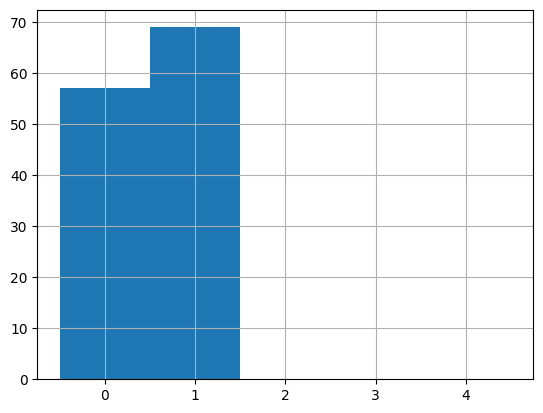

In [6]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()


outcomes=(np.unique(test_df['Outcome']))
le.fit(list(set(outcomes)))
y = le.transform( test_df['Outcome'] )



print ("Classes                          : ",(outcomes))
print ("Number of cpds in each class     : ",np.unique([len(y[y==smi]) for smi in y]))
print ("Total number of cpds             : ",len(y))

S =test_df['Outcome']
info = {}
for i,cls in enumerate(S.unique()):
    info.update({cls:i})
    S = S.replace(cls,i)

#GRAPH
ax = S.hist(bins=np.arange(-0.5,5))
ax.set_xticks(range(0,5))
info

## Data Cleansing and Preproc

In [7]:
x_rdkitcdk = test_df.drop(
    columns=[
        'RowID', 'Outcome',
        'ID', 'SMILES',
        'Morgan_Descriptors', 'MACCS_Descriptors', 'Modred_Descriptor',
        'Molecular Weight', 'Molecular weight', 'logP',
        'Molecule (RDKit Mol) (InChI Code)'
    ],
    errors='ignore'
)


In [8]:
x_rdkitcdk.shape

(126, 56)

In [9]:
x = x_rdkitcdk

In [10]:
test_df

,Outcome,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,ID,SMILES,Molecular Weight,logP,LabuteASA,TPSA,AMW,NumLipinskiHBA,NumLipinskiHBD,NumRotatableBonds,NumHBD,NumHBA,NumAmideBonds,NumHeteroAtoms,NumAtoms,NumRings,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,NumAromaticHeterocycles,NumSaturatedHeterocycles,NumAliphaticHeterocycles,NumAromaticCarbocycles,NumSaturatedCarbocycles,NumAliphaticCarbocycles,FractionCSP3,Chi0v,Chi1v,Chi2v,Chi3v,Chi4v,Chi1n,Chi2n,Chi3n,Chi4n,HallKierAlpha,kappa1,kappa2,kappa3,ALogP,ALogP2,AMR,MLogP,nAtomP,naAromAtom,bpol,nB,ECCEN,fragC,nHBAcc,nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3,Molecular weight,Molecule (RDKit Mol) (InChI Code),RowID
0,0.0,"[0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.3315345571001684, -0.04386761694440085, 0....",497,CCSC(=O)N(CC)C1CCCCC1,215.362,3.5141,91.427307,20.31,215.362,2,0,3,0,2,1,3,14,1,0,1,1,0,0,0,0,1,1,0.909091,10.107304,6.711266,4.992036,3.628613,2.826412,5.725667,3.776769,2.858478,2.135469,-0.18,11.892359,6.330981,3.192350,3.5141,12.348899,62.7810,3.5141,14.0,0,194.194,3,0.0,0.0,2,0,2,14.0,0.5,3,0.0,20.31,2.459331,3.5141,0.909091,215.362,InChI=1S/C11H21NOS/c1-3-12(11(13)14-4-2)10-8-6...,0
75,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-1.2546122139160842, -1.800999461140852, -1.8...",510,CCO[PH](=O)O,110.049,0.4049,36.890017,46.53,110.049,2,1,2,1,2,0,4,6,0,0,0,0,0,0,0,0,0,0,1.000000,4.470817,2.891347,1.519410,0.803439,0.370426,1.627637,0.698920,0.267813,0.123475,0.15,6.150000,3.344175,4.150000,0.4049,0.163944,22.8463,0.4049,6.0,0,102.993,2,0.0,0.0,2,1,2,6.0,0.5,2,0.0,46.53,2.831257,0.4049,1.000000,110.049,"InChI=1S/C2H7O3P/c1-2-5-6(3)4/h6H,2H2,1H3,(H,3,4)",75
73,0.0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.2615901048584381, 0.41500950467080966, 0.44...",364,CC(C)(C)C(O)C(=Cc1ccc(Cl)cc1)n1cncn1,291.782,3.3366,123.277871,50.94,291.782,4,1,3,1,4,0,5,20,2,2,0,0,1,0,0,1,0,0,0.333333,12.541550,6.757616,6.165803,3.220287,1.911319,6.379651,5.729367,2.968310,1.785331,-1.65,14.752754,5.770705,3.463721,3.3366,11.132900,81.1028,3.3366,20.0,2,273.638,3,0.0,0.0,4,1,4,20.0,0.5,3,0.0,50.94,2.440646,3.3366,0.333333,291.782,"InChI=1S/C15H18ClN3O/c1-15(2,3)14(20)13(19-10-...",73
69,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.45366682774401396, -0.49212655204912154, -0...",612,CCCCCCCCCCCC(=O)N(CCCC)CCCC,311.554,6.3361,139.594507,20.31,311.554,1,0,16,0,1,1,2,22,0,0,0,0,0,0,0,0,0,0,0.950000,15.669170,10.035060,6.666321,4.410071,2.804153,10.035060,6.666321,4.410071,2.804153,-0.53,21.470000,16.833935,13.155083,6.3361,40.146163,98.2400,6.3361,22.0,0,270.226,16,0.0,0.0,1,0,1,22.0,0.5,16,0.0,20.31,3.613823,6.3361,0.950000,311.554,InChI=1S/C20H41NO/c1-4-7-10-11-12-13-14-15-16-...,69
68,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.7854143455906262, -0.5653367076993612, -0....",541,CN(C)C(=S)SC(=S)N(C)C,208.377,1.4126,82.924299,6.48,208.377,3,0,0,0,3,0,5,11,0,0,0,0,0,0,0,0,0,0,0.666667,9.568662,4.685558,4.690486,3.214752,1.403649,3.052565,2.422731,0.904917,0.257265,0.13,11.130000,4.898031,4.550603,1.4126,1.995439,60.1610,1.4126,11.0,0,196.281,0,0.0,0.0,3,0,3,11.0,0.5,0,0.0,6.48,3.862410,1.4126,0.666667,208.377,InChI=1S/C6H12N2S3/c1-7(2)5(9)11-6(10)8(3)4/h1...,68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,1.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.2924037037931651, -0.30635950168936515, -0...",70,COCCNC(=O)CS

In [ ]:
'logP','LabuteASA', 'TPSA', 'AMW', 'NumLipinskiHBA', 'NumLipinskiHBD',
       'NumRotatableBonds', 'NumHBD', 'NumHBA', 'NumAmideBonds',
       'NumHeteroAtoms', 'NumAtoms', 'NumRings', 'NumAromaticRings',
       'NumSaturatedRings', 'NumAliphaticRings', 'NumAromaticHeterocycles',
       'NumSaturatedHeterocycles', 'NumAliphaticHeterocycles',
       'NumAromaticCarbocycles', 'NumSaturatedCarbocycles',
       'NumAliphaticCarbocycles', 'FractionCSP3', 'Chi0v', 'Chi1v', 'Chi2v',
       'Chi3v', 'Chi4v', 'Chi1n', 'Chi2n', 'Chi3n', 'Chi4n', 'HallKierAlpha',
       'kappa1', 'kappa2', 'kappa3', 'ALogP', 'ALogP2', 'AMR', 'MLogP',
       'nAtomP', 'bpol', 'nB', 'nHBAcc',
       'nHBDon', 'nAtomLAC', 'nAtomLC', 'PetitjeanNumber', 'nRotB',
       'LipinskiFailures', 'TopoPSA', 'VAdjMat', 'XLogP', 'Fsp3',
       'Molecular weight', 'fragC'

In [11]:
x_rdkitcdk  = x_rdkitcdk.apply(lambda row: row.values, axis=1).tolist()

# Add the new column 'rdkit_cdk' to test_df
test_df['rdkit_cdk'] = x_rdkitcdk 

# Display the updated DataFrame
print(test_df)

   Outcome                                 Morgan_Descriptors  \
0      0.0  [0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
75     0.0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
73     0.0  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
69     0.0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
68     0.0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
..     ...                                                ...   
77     1.0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...   
20     1.0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
21     1.0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
81     1.0  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
16     1.0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                    MACCS_Descriptors  \
0   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
75  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
73  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

## Data Initiate

In [12]:
y_test= np.int32((S))
x_test_morgan = np.array(list(test_df['Morgan_Descriptors']))
x_test_macckeys = np.array(list(test_df['MACCS_Descriptors']))
x_test_modred= np.array(list(test_df['Modred_Descriptor']))
x_test_rdkit_cdk = np.array(list(test_df['rdkit_cdk']))

In [13]:
x_test_rdkit_cdk

array([[9.14273068e+01, 2.03100000e+01, 2.15362000e+02, ...,
        2.45933122e+00, 3.51410000e+00, 9.09090909e-01],
       [3.68900175e+01, 4.65300000e+01, 1.10049000e+02, ...,
        2.83125711e+00, 4.04900000e-01, 1.00000000e+00],
       [1.23277871e+02, 5.09400000e+01, 2.91782000e+02, ...,
        2.44064598e+00, 3.33660000e+00, 3.33333333e-01],
       ...,
       [1.03686801e+02, 3.83300000e+01, 2.58104000e+02, ...,
        2.39630981e+00, 3.13070000e+00, 1.81818182e-01],
       [4.64253772e+01, 4.31400000e+01, 1.23539000e+02, ...,
        3.34341706e+00, 8.90400000e-01, 1.00000000e+00],
       [9.32947852e+01, 2.03100000e+01, 2.17243000e+02, ...,
        2.55869320e+00, 2.77210000e+00, 1.53846154e-01]])

In [14]:
import joblib
import numpy as np
import ast

# Function to ensure data is a NumPy array
def ensure_numpy_array(data):
    if isinstance(data, np.ndarray):
        return data
    elif isinstance(data, list):
        return np.array(data)
    elif hasattr(data, 'to_numpy'):  # For Pandas DataFrame
        return data.to_numpy()
    else:
        raise ValueError("Data format not recognized. Ensure it is a list, numpy array, or pandas DataFrame.")

# Function to check if all elements are numerical
def check_numerical(data):
    if not np.issubdtype(data.dtype, np.number):
        raise ValueError("Data contains non-numerical values. Ensure all elements are numerical.")

# Function to convert string representations of lists to numerical arrays
def parse_string_lists(data):
    parsed_data = []
    for item in data:
        if isinstance(item, str):
            try:
                parsed_item = ast.literal_eval(item)
                parsed_data.append(parsed_item)
            except (ValueError, SyntaxError):
                raise ValueError(f"Cannot parse value '{item}'")
        else:
            parsed_data.append(item)
    return np.array(parsed_data)

# Ensure training data is properly formatted
x_test_morgan = ensure_numpy_array(x_test_morgan)
x_test_macckeys = ensure_numpy_array(x_test_macckeys)
x_test_modred = ensure_numpy_array(x_test_modred)

check_numerical(x_test_morgan)
check_numerical(x_test_macckeys)

# Parse and convert string lists in x_test_modred
x_test_modred = parse_string_lists(x_test_modred)
check_numerical(x_test_modred)





In [15]:
x_test = np.concatenate((x_test_morgan, x_test_macckeys, x_test_modred), axis=1)

## Load .pkl Model

In [16]:
import joblib
import pickle

# ----------- DESKRIPTOR -----------
rf_morgan = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_RF_morgan.pkl')  
rf_maccs = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_RF_maccskey.pkl')
rf_modred = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_RF_modred.pkl')

svm_morgan = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_SVM_morgan.pkl')  
svm_maccs = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_SVM_maccskey.pkl')
svm_modred = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_SVM_modred.pkl')

xgb_morgan = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_XGB_morgan.pkl')  
xgb_maccs = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_XGB_maccskey.pkl')
xgb_modred = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_XGB_modred.pkl')



nn_morgan = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_NN_morgan.pkl')  
nn_maccs = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_NN_maccskey.pkl')
nn_modred = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_NN_modred.pkl')

lgbm_morgan = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_LGBM_morgan.pkl')  
lgbm_maccs = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_LGBM_maccskey.pkl')
lgbm_modred = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_LGBM_modred.pkl')



# ----------- FISIOKIMIA -----------
rf_p = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/physical chemical properties (model)/Model_Dermal_toxicity_RF_rdkit_cdk.pkl')
svm_p = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/physical chemical properties (model)/Model_Dermal_toxicity_SVM_rdkit_cdk.pkl')
xgb_p = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/physical chemical properties (model)/Model_Dermal_toxicity_XGB_rdkit_cdk.pkl')
nn_p = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/physical chemical properties (model)/Model_Dermal_toxicity_NN_rdkit_cdk.pkl')
lgbm_p = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/physical chemical properties (model)/Model_Dermal_toxicity_LGBM_rdkit_cdk.pkl')


In [17]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score, classification_report


## Scalling 

In [18]:
test_df['Outcome'].unique()

test_df['Outcome'].map(type).value_counts()



<class 'str'>    126
Name: Outcome, dtype: int64

In [19]:
y_true = (
    pd.to_numeric(test_df['Outcome'], errors='coerce')
    .astype(int)
)


In [20]:
import numpy as np
import joblib

try:
    scaler = joblib.load('train_scaler.pkl')
except FileNotFoundError:
    
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    x_temp = np.array(test_df['rdkit_cdk'].tolist())
    scaler.fit(x_temp)

# define x_test
x_test_raw = np.array(test_df['rdkit_cdk'].tolist())

x_test = scaler.transform(x_test_raw)

print(f"Shape x_test Sekarang: {x_test.shape}") 
# feature used (136, 56)

print(x_test[:5])

Shape x_test Sekarang: (126, 56)
[[-0.32070071 -0.56259164 -0.41807966 -0.52472666 -0.5916566  -0.31411526
  -0.5916566  -0.52472666  1.19142679 -0.58902898 -0.3690865  -0.30993786
  -0.79497578  0.84102145  0.62702859 -0.44925645 -0.26952685 -0.26952685
  -0.72660849  1.17677787  0.8660254   1.2196463  -0.22879969 -0.07130692
  -0.22504452 -0.17364461 -0.07321016  0.02378537 -0.14431392  0.08572843
   0.23968333  0.5781256  -0.2997254  -0.00907764 -0.14128362  0.22213873
  -0.09472311 -0.20093516  0.22213873 -0.3690865  -0.79497578 -0.46590609
  -0.31411526  0.          0.         -0.52472666 -0.5916566  -0.52472666
  -0.3690865   0.         -0.31411526  0.         -0.56259164 -0.35712349
   0.22213873  1.2196463 ]
 [-1.23507874 -0.13634672 -1.09149479 -0.52472666  0.04551205 -0.5364665
   0.04551205 -0.52472666 -0.42276434 -0.36945013 -1.13935399 -0.96080738
  -0.79497578 -0.37700961 -0.44061468 -0.44925645 -0.26952685 -0.26952685
  -0.72660849 -0.26277564 -0.34641016  1.48595238 -1.

In [21]:
x_test

array([[-0.32070071, -0.56259164, -0.41807966, ..., -0.35712349,
         0.22213873,  1.2196463 ],
       [-1.23507874, -0.13634672, -1.09149479, ...,  0.1138791 ,
        -1.13687796,  1.48595238],
       [ 0.21330926, -0.06465564,  0.07058161, ..., -0.38078626,
         0.14455432, -0.46695892],
       ...,
       [-0.11515671, -0.26964986, -0.14476953, ..., -0.43693307,
         0.0545564 , -0.9108024 ],
       [-1.07520788, -0.19145619, -1.00523412, ...,  0.76247246,
        -0.9246682 ,  1.48595238],
       [-0.28939036, -0.56259164, -0.40605176, ..., -0.23129265,
        -0.10218598, -0.99274274]])

In [22]:
import pandas as pd

# Pastikan Outcome numerik
y = pd.to_numeric(test_df['Outcome'], errors='coerce').dropna().astype(int)

class_counts = y.value_counts().sort_index()
class_ratio = class_counts / class_counts.sum()

print("Jumlah data per kelas:")
print(class_counts)

print("\nRasio kelas:")
print(class_ratio)


Jumlah data per kelas:
0    57
1    69
Name: Outcome, dtype: int64

Rasio kelas:
0    0.452381
1    0.547619
Name: Outcome, dtype: float64


In [23]:
# Cek apakah svm_p punya predict_proba
has_proba = hasattr(svm_p, "predict_proba")
print("SVM support predict_proba:", has_proba)


SVM support predict_proba: True


In [24]:
#BAD DATA 
import numpy as np

X = np.array(test_df['rdkit_cdk'].tolist())
print("=== dataset value check ===")
print("Min value:", np.min(X))
print("Max value:", np.max(X))
print("Mean:", np.mean(X))
print("Std:", np.std(X))



=== dataset value check ===
Min value: -9.540000000000001
Max value: 1167.1680000000001
Mean: 18.42794873382444
Std: 62.23725440208448


In [25]:
print("=== dataset imbalance check ===")
print(f"Total data: {len(y)}")
print(f"Class 0: {class_counts.get(0,0)}")
print(f"Class 1: {class_counts.get(1,0)}")
print(f"Imbalance ratio (1/0): {class_counts.get(1,1) / class_counts.get(0,1):.2f}")
print(f"SVM predict_proba available: {has_proba}")

# svm predict proba check
has_proba = hasattr(svm_p, "predict_proba")
print("SVM support predict_proba:", has_proba)



=== dataset imbalance check ===
Total data: 126
Class 0: 57
Class 1: 69
Imbalance ratio (1/0): 1.21
SVM predict_proba available: True
SVM support predict_proba: True


In [26]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score, roc_auc_score, f1_score
)

# PREPARE DATA
X_phys = np.array(test_df['rdkit_cdk'].tolist())

y_true = (
    pd.to_numeric(test_df['Outcome'], errors='coerce')
    .astype(int)
)

# SCALING DATA
scaler = StandardScaler()
X_phys_scaled = scaler.fit_transform(X_phys)

print("Scaling :")
print("Min:", X_phys_scaled.min())
print("Max:", X_phys_scaled.max())
print("Mean:", X_phys_scaled.mean())
print("Std:", X_phys_scaled.std())


Scaling :
Min: -5.489674467083587
Max: 11.012266721655942
Mean: -1.611208017596599e-17
Std: 0.9636241116594317


In [27]:
#SCALING

#RF
rf_probs = rf_p.predict_proba(X_phys_scaled)[:, 1]
rf_pred = (rf_probs > 0.5).astype(int)

conf_rf = confusion_matrix(y_true, rf_pred)
auc_rf = roc_auc_score(y_true, rf_probs)

print("=== RF RESULTS ===")
print("Confusion Matrix:\n", conf_rf)
print("Accuracy:", accuracy_score(y_true, rf_pred))
print("AUC:", auc_rf)
print("F1:", f1_score(y_true, rf_pred))

#SVM
svm_probs = svm_p.predict_proba(X_phys_scaled)[:, 1]
svm_pred = (svm_probs > 0.5).astype(int)

conf_svm = confusion_matrix(y_true, svm_pred)
auc_svm = roc_auc_score(y_true, svm_probs)

print("=== SVM RESULTS ===")
print("Confusion Matrix:\n", conf_svm)
print("Accuracy:", accuracy_score(y_true, svm_pred))
print("AUC:", auc_svm)
print("F1:", f1_score(y_true, svm_pred))

#XGB
xgb_probs = xgb_p.predict_proba(X_phys_scaled)[:, 1]
xgb_pred = (xgb_probs > 0.5).astype(int)

conf_xgb = confusion_matrix(y_true, xgb_pred)
auc_xgb = roc_auc_score(y_true, xgb_probs)

print("=== XGB RESULTS ===")
print("Confusion Matrix:\n", conf_xgb)
print("Accuracy:", accuracy_score(y_true, xgb_pred))
print("AUC:", auc_xgb)
print("F1:", f1_score(y_true, xgb_pred))

#NN
nn_probs = nn_p.predict_proba(X_phys_scaled)[:, 1]
nn_pred = (nn_probs > 0.5).astype(int)

conf_nn = confusion_matrix(y_true, nn_pred)
auc_nn = roc_auc_score(y_true, nn_probs)

print("=== NN RESULTS ===")
print("Confusion Matrix:\n", conf_nn)
print("Accuracy:", accuracy_score(y_true, nn_pred))
print("AUC:", auc_nn)
print("F1:", f1_score(y_true, nn_pred))

#LGBM
lgbm_probs = lgbm_p.predict_proba(X_phys_scaled)[:, 1]
lgbm_pred = (lgbm_probs > 0.5).astype(int)

conf_lgbm = confusion_matrix(y_true, lgbm_pred)
auc_lgbm = roc_auc_score(y_true, lgbm_probs)

print("=== LGBM RESULTS ===")
print("Confusion Matrix:\n", conf_lgbm)
print("Accuracy:", accuracy_score(y_true, lgbm_pred))
print("AUC:", auc_lgbm)
print("F1:", f1_score(y_true, lgbm_pred))


=== RF RESULTS ===
Confusion Matrix:
 [[42 15]
 [23 46]]
Accuracy: 0.6984126984126984
AUC: 0.7440884820747521
F1: 0.7076923076923077
=== SVM RESULTS ===
Confusion Matrix:
 [[48  9]
 [28 41]]
Accuracy: 0.7063492063492064
AUC: 0.7281973048563438
F1: 0.6890756302521008
=== XGB RESULTS ===
Confusion Matrix:
 [[46 11]
 [27 42]]
Accuracy: 0.6984126984126984
AUC: 0.7157386219171116
F1: 0.6885245901639344
=== NN RESULTS ===
Confusion Matrix:
 [[ 5 52]
 [ 4 65]]
Accuracy: 0.5555555555555556
AUC: 0.646325959827104
F1: 0.6989247311827957


C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


=== LGBM RESULTS ===
Confusion Matrix:
 [[43 14]
 [25 44]]
Accuracy: 0.6904761904761905
AUC: 0.7287058225273328
F1: 0.6929133858267716


In [28]:
#DESKRIPTOR INITATE & INPUT SHAPE
def test_descriptor_ready(model, X, name):
    print(f"\n=== TEST MODEL: {name} ===")
    print("Input shape:", X.shape)
    probs = model.predict_proba(X)[:, 1]
    print("predict_proba OK | output shape:", probs.shape)

X_morgan = np.array(test_df['Morgan_Descriptors'].tolist())
X_maccs  = np.array(test_df['MACCS_Descriptors'].tolist())
X_modred = np.array(test_df['Modred_Descriptor'].tolist())

test_descriptor_ready(rf_morgan, X_morgan, "RF Morgan")
test_descriptor_ready(svm_maccs, X_maccs, "SVM MACCS")
test_descriptor_ready(xgb_modred, X_modred, "XGB ModRed")
test_descriptor_ready(nn_morgan, X_morgan, "NN Morgan")
test_descriptor_ready(lgbm_maccs, X_maccs, "LGBM MACCS")




=== TEST MODEL: RF Morgan ===
Input shape: (126, 1024)
predict_proba OK | output shape: (126,)

=== TEST MODEL: SVM MACCS ===
Input shape: (126, 167)
predict_proba OK | output shape: (126,)

=== TEST MODEL: XGB ModRed ===
Input shape: (126, 794)
predict_proba OK | output shape: (126,)

=== TEST MODEL: NN Morgan ===
Input shape: (126, 1024)
predict_proba OK | output shape: (126,)

=== TEST MODEL: LGBM MACCS ===
Input shape: (126, 167)
predict_proba OK | output shape: (126,)


## Physiochemical Consensus and Individual

In [29]:
#Phys only 
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df, scaler):

    X_test = np.array(test_df['rdkit_cdk'].tolist())
    X_test_scaled = scaler.transform(X_test)

    rf_probs_rdkitcdk = rf_p.predict_proba(X_test_scaled)[:, 1]   # Probabilities for class 1
    xgb_probs_rdkitcdk = xgb_p.predict_proba(X_test_scaled)[:, 1]  # Probabilities for class 1
    svm_probs_rdkitcdk = svm_p.predict_proba(X_test_scaled)[:, 1]  # Probabilities for class 1

    # Calculate the mean probability across RF and XGB models
    mean_probs = np.mean([rf_probs_rdkitcdk, xgb_probs_rdkitcdk], axis=0)

    # Convert mean probabilities to final class predictions (e.g., threshold at 0.5)
    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs, rf_probs_rdkitcdk, xgb_probs_rdkitcdk, svm_probs_rdkitcdk


# Run prediction
final_predictions, mean_probs, rf_probs, xgb_probs, svm_probs = predict_with_models_probabilities(test_df, scaler)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs
test_df['RF_Probabilities'] = rf_probs
test_df['XGB_Probabilities'] = xgb_probs
test_df['SVM_Probabilities'] = svm_probs

y_true = pd.to_numeric(test_df['Outcome'], errors='coerce').astype(int)

conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix (Consensus):")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy (Consensus):", accuracy)

auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score (Consensus):", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score (Consensus):", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print("Sensitivity (Consensus):", sensitivity)
print("Specificity (Consensus):", specificity)

ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate) (Consensus):", ccr)

ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value) (Consensus):", ppv)

npv = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value) (Consensus):", npv)

# Evaluate RF model alone
rf_predictions = (rf_probs > 0.5).astype(int)
conf_matrix_rf = confusion_matrix(y_true, rf_predictions)
print("Confusion Matrix (RF):")
print(conf_matrix_rf)

accuracy_rf = accuracy_score(y_true, rf_predictions)
print("Accuracy (RF):", accuracy_rf)

auc_score_rf = roc_auc_score(y_true, rf_probs)
print("AUC Score (RF):", auc_score_rf)

f1_rf = f1_score(y_true, rf_predictions, average='binary')
print("F1 Score (RF):", f1_rf)

tn, fp, fn, tp = conf_matrix_rf.ravel()
sensitivity_rf = tp / (tp + fn)
specificity_rf = tn / (tn + fp)
print("Sensitivity (RF):", sensitivity_rf)
print("Specificity (RF):", specificity_rf)

ccr_rf = (sensitivity_rf + specificity_rf) / 2
print("CCR (Correct Classification Rate) (RF):", ccr_rf)

ppv_rf = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value) (RF):", ppv_rf)

npv_rf = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value) (RF):", npv_rf)

# Evaluate XGB model alone
xgb_predictions = (xgb_probs > 0.5).astype(int)
conf_matrix_xgb = confusion_matrix(y_true, xgb_predictions)
print("Confusion Matrix (XGB):")
print(conf_matrix_xgb)

accuracy_xgb = accuracy_score(y_true, xgb_predictions)
print("Accuracy (XGB):", accuracy_xgb)

auc_score_xgb = roc_auc_score(y_true, xgb_probs)
print("AUC Score (XGB):", auc_score_xgb)

f1_xgb = f1_score(y_true, xgb_predictions, average='binary')
print("F1 Score (XGB):", f1_xgb)

tn, fp, fn, tp = conf_matrix_xgb.ravel()
sensitivity_xgb = tp / (tp + fn)
specificity_xgb = tn / (tn + fp)
print("Sensitivity (XGB):", sensitivity_xgb)
print("Specificity (XGB):", specificity_xgb)

ccr_xgb = (sensitivity_xgb + specificity_xgb) / 2
print("CCR (Correct Classification Rate) (XGB):", ccr_xgb)

ppv_xgb = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value) (XGB):", ppv_xgb)

npv_xgb = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value) (XGB):", npv_xgb)

# Evaluate SVM model alone
svm_predictions = (svm_probs > 0.5).astype(int)
conf_matrix_svm = confusion_matrix(y_true, svm_predictions)
print("Confusion Matrix (SVM):")
print(conf_matrix_svm)

accuracy_svm = accuracy_score(y_true, svm_predictions)
print("Accuracy (SVM):", accuracy_svm)

auc_score_svm = roc_auc_score(y_true, svm_probs)
print("AUC Score (SVM):", auc_score_svm)

f1_svm = f1_score(y_true, svm_predictions, average='binary')
print("F1 Score (SVM):", f1_svm)

tn, fp, fn, tp = conf_matrix_svm.ravel()
sensitivity_svm = tp / (tp + fn)
specificity_svm = tn / (tn + fp)
print("Sensitivity (SVM):", sensitivity_svm)
print("Specificity (SVM):", specificity_svm)

ccr_svm = (sensitivity_svm + specificity_svm) / 2
print("CCR (Correct Classification Rate) (SVM):", ccr_svm)

ppv_svm = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value) (SVM):", ppv_svm)

npv_svm = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value) (SVM):", npv_svm)

Confusion Matrix (Consensus):
[[46 11]
 [24 45]]
Accuracy (Consensus): 0.7222222222222222
AUC Score (Consensus): 0.7424357996440376
F1 Score (Consensus): 0.72
Sensitivity (Consensus): 0.6521739130434783
Specificity (Consensus): 0.8070175438596491
CCR (Correct Classification Rate) (Consensus): 0.7295957284515637
PPV (Positive Predictive Value) (Consensus): 0.8035714285714286
NPV (Negative Predictive Value) (Consensus): 0.6571428571428571
Confusion Matrix (RF):
[[42 15]
 [23 46]]
Accuracy (RF): 0.6984126984126984
AUC Score (RF): 0.7440884820747521
F1 Score (RF): 0.7076923076923077
Sensitivity (RF): 0.6666666666666666
Specificity (RF): 0.7368421052631579
CCR (Correct Classification Rate) (RF): 0.7017543859649122
PPV (Positive Predictive Value) (RF): 0.7540983606557377
NPV (Negative Predictive Value) (RF): 0.6461538461538462
Confusion Matrix (XGB):
[[46 11]
 [27 42]]
Accuracy (XGB): 0.6984126984126984
AUC Score (XGB): 0.7157386219171116
F1 Score (XGB): 0.6885245901639344
Sensitivity (XGB):

In [30]:
#PHYSICOCHEMICAL ONLY - 5 algoritma (RF, XGB, SVM, NN, LGBM)
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df, scaler):
    X_test = np.array(test_df['rdkit_cdk'].tolist())
    X_test_scaled = scaler.transform(X_test)

    rf_probs = rf_p.predict_proba(X_test_scaled)[:, 1]
    xgb_probs = xgb_p.predict_proba(X_test_scaled)[:, 1]
    svm_probs = svm_p.predict_proba(X_test_scaled)[:, 1]
    nn_probs = nn_p.predict_proba(X_test_scaled)[:, 1]
    lgbm_probs = lgbm_p.predict_proba(X_test_scaled)[:, 1]

    # Calculate the mean probability across all 5 models
    mean_probs = np.mean([rf_probs, xgb_probs, svm_probs, nn_probs, lgbm_probs], axis=0)

    # Convert mean probabilities to final class predictions (threshold at 0.5)
    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs, rf_probs, xgb_probs, svm_probs, nn_probs, lgbm_probs


# Run prediction
final_predictions, mean_probs, rf_probs, xgb_probs, svm_probs, nn_probs, lgbm_probs = predict_with_models_probabilities(test_df, scaler)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs
test_df['RF_Probabilities'] = rf_probs
test_df['XGB_Probabilities'] = xgb_probs
test_df['SVM_Probabilities'] = svm_probs
test_df['NN_Probabilities'] = nn_probs
test_df['LGBM_Probabilities'] = lgbm_probs

y_true = pd.to_numeric(test_df['Outcome'], errors='coerce').astype(int)


def evaluate_model(y_true, probs, label):
    predictions = (probs > 0.5).astype(int)
    cm = confusion_matrix(y_true, predictions)
    print(f"Confusion Matrix ({label}):")
    print(cm)

    accuracy = accuracy_score(y_true, predictions)
    print(f"Accuracy ({label}):", accuracy)

    auc_score = roc_auc_score(y_true, probs)
    print(f"AUC Score ({label}):", auc_score)

    f1 = f1_score(y_true, predictions, average='binary')
    print(f"F1 Score ({label}):", f1)

    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    print(f"Sensitivity ({label}):", sensitivity)
    print(f"Specificity ({label}):", specificity)

    ccr = (sensitivity + specificity) / 2
    print(f"CCR (Correct Classification Rate) ({label}):", ccr)

    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    print(f"PPV (Positive Predictive Value) ({label}):", ppv)

    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    print(f"NPV (Negative Predictive Value) ({label}):", npv)
    print()  # spacer antar model

    return {
        "accuracy": accuracy, "auc": auc_score, "f1": f1,
        "sensitivity": sensitivity, "specificity": specificity,
        "ccr": ccr, "ppv": ppv, "npv": npv
    }


# Evaluate consensus and each individual model
results_consensus = evaluate_model(y_true, mean_probs, "Consensus")
results_rf = evaluate_model(y_true, rf_probs, "RF")
results_xgb = evaluate_model(y_true, xgb_probs, "XGB")
results_svm = evaluate_model(y_true, svm_probs, "SVM")
results_nn = evaluate_model(y_true, nn_probs, "NN")
results_lgbm = evaluate_model(y_true, lgbm_probs, "LGBM")

Confusion Matrix (Consensus):
[[45 12]
 [23 46]]
Accuracy (Consensus): 0.7222222222222222
AUC Score (Consensus): 0.7429443173150267
F1 Score (Consensus): 0.7244094488188977
Sensitivity (Consensus): 0.6666666666666666
Specificity (Consensus): 0.7894736842105263
CCR (Correct Classification Rate) (Consensus): 0.7280701754385965
PPV (Positive Predictive Value) (Consensus): 0.7931034482758621
NPV (Negative Predictive Value) (Consensus): 0.6617647058823529

Confusion Matrix (RF):
[[42 15]
 [23 46]]
Accuracy (RF): 0.6984126984126984
AUC Score (RF): 0.7440884820747521
F1 Score (RF): 0.7076923076923077
Sensitivity (RF): 0.6666666666666666
Specificity (RF): 0.7368421052631579
CCR (Correct Classification Rate) (RF): 0.7017543859649122
PPV (Positive Predictive Value) (RF): 0.7540983606557377
NPV (Negative Predictive Value) (RF): 0.6461538461538462

Confusion Matrix (XGB):
[[46 11]
 [27 42]]
Accuracy (XGB): 0.6984126984126984
AUC Score (XGB): 0.7157386219171116
F1 Score (XGB): 0.6885245901639344
Se

C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


## Consensus Physiochemical and Mol Desc

In [31]:
#Persis dengan bu yunen
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df, scaler):
    morgan_probs = rf_morgan.predict_proba(np.array(test_df['Morgan_Descriptors'].tolist()))[:, 1]
    maccs_probs = rf_maccs.predict_proba(np.array(test_df['MACCS_Descriptors'].tolist()))[:, 1]
    modred_probs = rf_modred.predict_proba(np.array(test_df['Modred_Descriptor'].tolist()))[:, 1]

    # Physicochemical, perlu di-scale dulu
    X_test = np.array(test_df['rdkit_cdk'].tolist())
    X_test_scaled = scaler.transform(X_test)

    rf_probs_rdkitcdk = rf_p.predict_proba(X_test_scaled)[:, 1]
    xgb_probs_rdkitcdk = xgb_p.predict_proba(X_test_scaled)[:, 1]

    # Calculate the mean probability across all models
    mean_probs = np.mean([morgan_probs, maccs_probs, modred_probs, xgb_probs_rdkitcdk], axis=0)
    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs


# Run prediction
final_predictions, mean_probs = predict_with_models_probabilities(test_df, scaler)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs

y_true = pd.to_numeric(test_df['Outcome'], errors='coerce').astype(int)

# Now you can calculate AUC using mean_probs
conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

# Calculate AUC using mean probabilities
auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

# Correct Classification Rate (CCR)
ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

# Positive Predictive Value (PPV)
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value):", ppv)

# Negative Predictive Value (NPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value):", npv)

Confusion Matrix:
[[45 12]
 [22 47]]
Accuracy: 0.7301587301587301
AUC Score: 0.8243071446732774
F1 Score: 0.734375
Sensitivity: 0.6811594202898551
Specificity: 0.7894736842105263
CCR (Correct Classification Rate): 0.7353165522501908
PPV (Positive Predictive Value): 0.7966101694915254
NPV (Negative Predictive Value): 0.6716417910447762


In [32]:
# rf xgb svm
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df, scaler):
    morgan_probs = rf_morgan.predict_proba(np.array(test_df['Morgan_Descriptors'].tolist()))[:, 1]
    maccs_probs = xgb_maccs.predict_proba(np.array(test_df['MACCS_Descriptors'].tolist()))[:, 1]
    modred_probs = svm_modred.predict_proba(np.array(test_df['Modred_Descriptor'].tolist()))[:, 1]

    # Physicochemical, perlu di-scale dulu
    X_test = np.array(test_df['rdkit_cdk'].tolist())
    X_test_scaled = scaler.transform(X_test)

    rf_probs_rdkitcdk = rf_p.predict_proba(X_test_scaled)[:, 1]
    xgb_probs_rdkitcdk = xgb_p.predict_proba(X_test_scaled)[:, 1]

    # Calculate the mean probability across all models
    mean_probs = np.mean([morgan_probs, maccs_probs, modred_probs, xgb_probs_rdkitcdk], axis=0)
    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs


# Run prediction
final_predictions, mean_probs = predict_with_models_probabilities(test_df, scaler)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs

y_true = pd.to_numeric(test_df['Outcome'], errors='coerce').astype(int)

# Now you can calculate AUC using mean_probs
conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

# Calculate AUC using mean probabilities
auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

# Correct Classification Rate (CCR)
ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

# Positive Predictive Value (PPV)
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value):", ppv)

# Negative Predictive Value (NPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value):", npv)

Confusion Matrix:
[[43 14]
 [23 46]]
Accuracy: 0.7063492063492064
AUC Score: 0.8194762267988812
F1 Score: 0.7131782945736435
Sensitivity: 0.6666666666666666
Specificity: 0.7543859649122807
CCR (Correct Classification Rate): 0.7105263157894737
PPV (Positive Predictive Value): 0.7666666666666667
NPV (Negative Predictive Value): 0.6515151515151515


In [33]:
# rf xgb svm
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df, scaler):
    morgan_probs = rf_morgan.predict_proba(np.array(test_df['Morgan_Descriptors'].tolist()))[:, 1]
    maccs_probs = xgb_maccs.predict_proba(np.array(test_df['MACCS_Descriptors'].tolist()))[:, 1]
    modred_probs = svm_modred.predict_proba(np.array(test_df['Modred_Descriptor'].tolist()))[:, 1]

    # Physicochemical, perlu di-scale dulu
    X_test = np.array(test_df['rdkit_cdk'].tolist())
    X_test_scaled = scaler.transform(X_test)

    nn_probs_rdkitcdk = nn_p.predict_proba(X_test_scaled)[:, 1]
    lgbm_probs_rdkitcdk = lgbm_p.predict_proba(X_test_scaled)[:, 1]

    # Calculate the mean probability across all models
    mean_probs = np.mean([morgan_probs, maccs_probs, modred_probs, nn_probs_rdkitcdk], axis=0)
    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs


# Run prediction
final_predictions, mean_probs = predict_with_models_probabilities(test_df, scaler)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs

y_true = pd.to_numeric(test_df['Outcome'], errors='coerce').astype(int)

# Now you can calculate AUC using mean_probs
conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

# Calculate AUC using mean probabilities
auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

# Correct Classification Rate (CCR)
ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

# Positive Predictive Value (PPV)
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value):", ppv)

# Negative Predictive Value (NPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value):", npv)

Confusion Matrix:
[[43 14]
 [21 48]]
Accuracy: 0.7222222222222222
AUC Score: 0.8304093567251462
F1 Score: 0.732824427480916
Sensitivity: 0.6956521739130435
Specificity: 0.7543859649122807
CCR (Correct Classification Rate): 0.7250190694126621
PPV (Positive Predictive Value): 0.7741935483870968
NPV (Negative Predictive Value): 0.671875


C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


In [ ]:
test_df = load_sdf_to_df(r'C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Dermal toxicity\dataset\test_set_acute_dermal_features.sdf')


## Read Accross

In [34]:
#Read-Across (Tanimoto Similarity, Morgan Fingerprint, k=5, weighted) - Dermal

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score
from rdkit import DataStructs
from rdkit.DataStructs import ExplicitBitVect

# ===== Load train_df =====
train_df = load_sdf_to_df(r'C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Dermal toxicity\dataset\test_set_acute_dermal_features.sdf')

def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string


train_df['Morgan_Descriptors'] = train_df['Morgan_Descriptors'].apply(string_to_list)
train_df['MACCS_Descriptors'] = train_df['MACCS_Descriptors'].apply(string_to_list)

print("Train DataFrame:")
print(train_df.head())
print(train_df.shape)


# ===== Fungsi Read-Across =====
def tanimoto_similarity_matrix(query_fps, ref_fps):
    n_query = query_fps.shape[0]
    n_ref = ref_fps.shape[0]
    sim_matrix = np.zeros((n_query, n_ref))

    ref_bitvecs = []
    for row in ref_fps:
        bv = ExplicitBitVect(len(row))
        on_bits = np.where(row == 1)[0].tolist()
        bv.SetBitsFromList(on_bits)
        ref_bitvecs.append(bv)

    for i, q_row in enumerate(query_fps):
        q_bv = ExplicitBitVect(len(q_row))
        q_on_bits = np.where(q_row == 1)[0].tolist()
        q_bv.SetBitsFromList(q_on_bits)
        sims = DataStructs.BulkTanimotoSimilarity(q_bv, ref_bitvecs)
        sim_matrix[i, :] = sims

    return sim_matrix


def read_across_predict(X_test_fp, X_train_fp, y_train, k=5):
    sim_matrix = tanimoto_similarity_matrix(X_test_fp, X_train_fp)
    predictions_proba = np.zeros(X_test_fp.shape[0])

    for i in range(X_test_fp.shape[0]):
        sims = sim_matrix[i, :]
        top_k_idx = np.argsort(sims)[::-1][:k]
        top_k_sims = sims[top_k_idx]
        top_k_labels = y_train[top_k_idx]

        total_sim = np.sum(top_k_sims)
        if total_sim > 0:
            weighted_pred = np.sum(top_k_sims * top_k_labels) / total_sim
        else:
            weighted_pred = np.mean(top_k_labels)
        predictions_proba[i] = weighted_pred

    return predictions_proba


# ===== Siapkan data =====
X_train_morgan = np.array(train_df['Morgan_Descriptors'].tolist())
y_train = pd.to_numeric(train_df['Outcome'], errors='coerce').astype(int).values

X_test_morgan = np.array(test_df['Morgan_Descriptors'].tolist())
y_true = pd.to_numeric(test_df['Outcome'], errors='coerce').astype(int)

# ===== Jalankan read-across =====
readacross_probs = read_across_predict(X_test_morgan, X_train_morgan, y_train, k=5)
readacross_predictions = (readacross_probs > 0.5).astype(int)

test_df['ReadAcross_Probabilities'] = readacross_probs
test_df['ReadAcross_Predictions'] = readacross_predictions

# ===== Evaluasi =====
conf_matrix_ra = confusion_matrix(y_true, readacross_predictions)
print("Confusion Matrix (Read-Across):")
print(conf_matrix_ra)

accuracy_ra = accuracy_score(y_true, readacross_predictions)
print("Accuracy (Read-Across):", accuracy_ra)

auc_score_ra = roc_auc_score(y_true, readacross_probs)
print("AUC Score (Read-Across):", auc_score_ra)

f1_ra = f1_score(y_true, readacross_predictions, average='binary')
print("F1 Score (Read-Across):", f1_ra)

tn, fp, fn, tp = conf_matrix_ra.ravel()
sensitivity_ra = tp / (tp + fn)
specificity_ra = tn / (tn + fp)
print("Sensitivity (Read-Across):", sensitivity_ra)
print("Specificity (Read-Across):", specificity_ra)

ccr_ra = (sensitivity_ra + specificity_ra) / 2
print("CCR (Correct Classification Rate) (Read-Across):", ccr_ra)

ppv_ra = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value) (Read-Across):", ppv_ra)

npv_ra = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value) (Read-Across):", npv_ra)

Train DataFrame:
  Outcome                                 Morgan_Descriptors  \
0     0.0  [0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1     1.0  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
2     0.0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
3     1.0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
4     0.0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   MACCS_Descriptors  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
2  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
3  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
4  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   Modred_Descriptor   ID  \
0  [-0.3315345571001684, -0.04386761694440085, 0....  497   
1  [-0.4567077543031368, 0.024564669463881604, 0....  245   
2  [0.5742766649415614, 1.461928059334721, 1.5534...  554   
3  [-1.4771754614

## READ across Maccs keys

In [35]:
#Read-Across (Tanimoto Similarity, Morgan Fingerprint, k=5, weighted) - dermal

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score
from rdkit import DataStructs
from rdkit.DataStructs import ExplicitBitVect

# ===== Load train_df =====
train_df = load_sdf_to_df(r'C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Dermal toxicity\dataset\test_set_acute_dermal_features.sdf')

def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string

train_df = train_df.rename(columns={"labels": "Outcome"})


train_df['Morgan_Descriptors'] = train_df['Morgan_Descriptors'].apply(string_to_list)
train_df['MACCS_Descriptors'] = train_df['MACCS_Descriptors'].apply(string_to_list)

print("Train DataFrame:")
print(train_df.head())
print(train_df.shape)


# ===== Fungsi Read-Across =====
def tanimoto_similarity_matrix(query_fps, ref_fps):
    n_query = query_fps.shape[0]
    n_ref = ref_fps.shape[0]
    sim_matrix = np.zeros((n_query, n_ref))

    ref_bitvecs = []
    for row in ref_fps:
        bv = ExplicitBitVect(len(row))
        on_bits = np.where(row == 1)[0].tolist()
        bv.SetBitsFromList(on_bits)
        ref_bitvecs.append(bv)

    for i, q_row in enumerate(query_fps):
        q_bv = ExplicitBitVect(len(q_row))
        q_on_bits = np.where(q_row == 1)[0].tolist()
        q_bv.SetBitsFromList(q_on_bits)
        sims = DataStructs.BulkTanimotoSimilarity(q_bv, ref_bitvecs)
        sim_matrix[i, :] = sims

    return sim_matrix


def read_across_predict(X_test_fp, X_train_fp, y_train, k=5, power=1):
    sim_matrix = tanimoto_similarity_matrix(X_test_fp, X_train_fp)
    predictions_proba = np.zeros(X_test_fp.shape[0])

    for i in range(X_test_fp.shape[0]):
        sims = sim_matrix[i, :]
        top_k_idx = np.argsort(sims)[::-1][:k]
        top_k_sims = sims[top_k_idx]
        top_k_labels = y_train[top_k_idx]

        # ----- Bobot dipangkatkan (power=1: linear, power=2: kuadrat, dst) -----
        top_k_weights = top_k_sims ** power

        total_weight = np.sum(top_k_weights)
        if total_weight > 0:
            weighted_pred = np.sum(top_k_weights * top_k_labels) / total_weight
        else:
            weighted_pred = np.mean(top_k_labels)
        predictions_proba[i] = weighted_pred

    return predictions_proba


# ===== Siapkan data =====
X_train_morgan = np.array(train_df['MACCS_Descriptors'].tolist())
y_train = pd.to_numeric(train_df['Outcome'], errors='coerce').astype(int).values

X_test_morgan = np.array(test_df['MACCS_Descriptors'].tolist())
y_true = pd.to_numeric(test_df['Outcome'], errors='coerce').astype(int)

# ===== Jalankan read-across =====
readacross_probs = read_across_predict(X_test_morgan, X_train_morgan, y_train, k=5)
readacross_predictions = (readacross_probs > 0.5).astype(int)

test_df['ReadAcross_Probabilities'] = readacross_probs
test_df['ReadAcross_Predictions'] = readacross_predictions

# ===== Evaluasi =====
conf_matrix_ra = confusion_matrix(y_true, readacross_predictions)
print("Confusion Matrix MACCS (Read-Across):")
print(conf_matrix_ra)

accuracy_ra = accuracy_score(y_true, readacross_predictions)
print("Accuracy (Read-Across):", accuracy_ra)

auc_score_ra = roc_auc_score(y_true, readacross_probs)
print("AUC Score (Read-Across):", auc_score_ra)

f1_ra = f1_score(y_true, readacross_predictions, average='binary')
print("F1 Score (Read-Across):", f1_ra)

tn, fp, fn, tp = conf_matrix_ra.ravel()
sensitivity_ra = tp / (tp + fn)
specificity_ra = tn / (tn + fp)
print("Sensitivity (Read-Across):", sensitivity_ra)
print("Specificity (Read-Across):", specificity_ra)

ccr_ra = (sensitivity_ra + specificity_ra) / 2
print("CCR (Correct Classification Rate) (Read-Across):", ccr_ra)

ppv_ra = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value) (Read-Across):", ppv_ra)

npv_ra = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value) (Read-Across):", npv_ra)

Train DataFrame:
  Outcome                                 Morgan_Descriptors  \
0     0.0  [0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1     1.0  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
2     0.0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
3     1.0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
4     0.0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   MACCS_Descriptors  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
2  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
3  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
4  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   Modred_Descriptor   ID  \
0  [-0.3315345571001684, -0.04386761694440085, 0....  497   
1  [-0.4567077543031368, 0.024564669463881604, 0....  245   
2  [0.5742766649415614, 1.461928059334721, 1.5534...  554   
3  [-1.4771754614

## QRASAR Morgan

In [36]:
#rf xgb svm(p) rf(p) + read-across
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score
from rdkit import DataStructs
from rdkit.DataStructs import ExplicitBitVect

# ===== Fungsi Read-Across =====
def tanimoto_similarity_matrix(query_fps, ref_fps):
    n_query = query_fps.shape[0]
    n_ref = ref_fps.shape[0]
    sim_matrix = np.zeros((n_query, n_ref))

    ref_bitvecs = []
    for row in ref_fps:
        bv = ExplicitBitVect(len(row))
        on_bits = np.where(row == 1)[0].tolist()
        bv.SetBitsFromList(on_bits)
        ref_bitvecs.append(bv)

    for i, q_row in enumerate(query_fps):
        q_bv = ExplicitBitVect(len(q_row))
        q_on_bits = np.where(q_row == 1)[0].tolist()
        q_bv.SetBitsFromList(q_on_bits)
        sims = DataStructs.BulkTanimotoSimilarity(q_bv, ref_bitvecs)
        sim_matrix[i, :] = sims

    return sim_matrix


def read_across_predict(X_test_fp, X_train_fp, y_train, k=5):
    sim_matrix = tanimoto_similarity_matrix(X_test_fp, X_train_fp)
    predictions_proba = np.zeros(X_test_fp.shape[0])

    for i in range(X_test_fp.shape[0]):
        sims = sim_matrix[i, :]
        top_k_idx = np.argsort(sims)[::-1][:k]
        top_k_sims = sims[top_k_idx]
        top_k_labels = y_train[top_k_idx]

        total_sim = np.sum(top_k_sims)
        if total_sim > 0:
            weighted_pred = np.sum(top_k_sims * top_k_labels) / total_sim
        else:
            weighted_pred = np.mean(top_k_labels)
        predictions_proba[i] = weighted_pred

    return predictions_proba


# ===== Fungsi konsensus utama =====
def predict_with_models_probabilities(test_df, train_df, k_readacross=5):
    morgan_probs = rf_morgan.predict_proba(np.array(test_df['Morgan_Descriptors'].tolist()))[:, 1]
    maccs_probs = xgb_maccs.predict_proba(np.array(test_df['MACCS_Descriptors'].tolist()))[:, 1]
    modred_probs = svm_modred.predict_proba(np.array(test_df['Modred_Descriptor'].tolist()))[:, 1]
    nn_probs_rdkitcdk = nn_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    lgbm_probs_rdkitcdk = lgbm_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]

    # ----- Read-Across -----
    X_train_morgan = np.array(train_df['Morgan_Descriptors'].tolist())
    y_train_ra = pd.to_numeric(train_df['Outcome'], errors='coerce').astype(int).values
    X_test_morgan = np.array(test_df['Morgan_Descriptors'].tolist())

    readacross_probs = read_across_predict(X_test_morgan, X_train_morgan, y_train_ra, k=k_readacross)

    # ----- Konsensus (7 komponen) -----
    mean_probs = np.mean([morgan_probs, maccs_probs, modred_probs,lgbm_probs_rdkitcdk, nn_probs_rdkitcdk,
    readacross_probs,readacross_probs
    ], axis=0)
    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs, readacross_probs


# Run prediction
final_predictions, mean_probs, readacross_probs = predict_with_models_probabilities(test_df, train_df, k_readacross=5)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs
test_df['ReadAcross_Probabilities'] = readacross_probs

y_true = pd.to_numeric(test_df['Outcome'], errors='coerce').astype(int)

# Now you can calculate AUC using mean_probs
conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value):", ppv)

npv = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value):", npv)

Confusion Matrix:
[[54  3]
 [18 51]]
Accuracy: 0.8333333333333334
AUC Score: 0.9511823035850495
F1 Score: 0.8292682926829268
Sensitivity: 0.7391304347826086
Specificity: 0.9473684210526315
CCR (Correct Classification Rate): 0.8432494279176201
PPV (Positive Predictive Value): 0.9444444444444444
NPV (Negative Predictive Value): 0.75


C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


## QRASAR Maccs keys

In [37]:
#rf xgb svm(p) rf(p) + read-across
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score
from rdkit import DataStructs
from rdkit.DataStructs import ExplicitBitVect

# ===== Fungsi Read-Across =====
def tanimoto_similarity_matrix(query_fps, ref_fps):
    n_query = query_fps.shape[0]
    n_ref = ref_fps.shape[0]
    sim_matrix = np.zeros((n_query, n_ref))

    ref_bitvecs = []
    for row in ref_fps:
        bv = ExplicitBitVect(len(row))
        on_bits = np.where(row == 1)[0].tolist()
        bv.SetBitsFromList(on_bits)
        ref_bitvecs.append(bv)

    for i, q_row in enumerate(query_fps):
        q_bv = ExplicitBitVect(len(q_row))
        q_on_bits = np.where(q_row == 1)[0].tolist()
        q_bv.SetBitsFromList(q_on_bits)
        sims = DataStructs.BulkTanimotoSimilarity(q_bv, ref_bitvecs)
        sim_matrix[i, :] = sims

    return sim_matrix


def read_across_predict(X_test_fp, X_train_fp, y_train, k=5):
    sim_matrix = tanimoto_similarity_matrix(X_test_fp, X_train_fp)
    predictions_proba = np.zeros(X_test_fp.shape[0])

    for i in range(X_test_fp.shape[0]):
        sims = sim_matrix[i, :]
        top_k_idx = np.argsort(sims)[::-1][:k]
        top_k_sims = sims[top_k_idx]
        top_k_labels = y_train[top_k_idx]

        total_sim = np.sum(top_k_sims)
        if total_sim > 0:
            weighted_pred = np.sum(top_k_sims * top_k_labels) / total_sim
        else:
            weighted_pred = np.mean(top_k_labels)
        predictions_proba[i] = weighted_pred

    return predictions_proba


# ===== Fungsi konsensus utama =====
def predict_with_models_probabilities(test_df, train_df, k_readacross=5):
    morgan_probs = rf_morgan.predict_proba(np.array(test_df['Morgan_Descriptors'].tolist()))[:, 1]
    maccs_probs = xgb_maccs.predict_proba(np.array(test_df['MACCS_Descriptors'].tolist()))[:, 1]
    modred_probs = svm_modred.predict_proba(np.array(test_df['Modred_Descriptor'].tolist()))[:, 1]
    nn_probs_rdkitcdk = nn_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    lgbm_probs_rdkitcdk = lgbm_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]


    # ----- Read-Across -----
    X_train_maccs = np.array(train_df['MACCS_Descriptors'].tolist())
    y_train_ra = pd.to_numeric(train_df['Outcome'], errors='coerce').astype(int).values
    X_test_maccs = np.array(test_df['MACCS_Descriptors'].tolist())

    readacross_probs = read_across_predict(X_test_maccs, X_train_maccs, y_train_ra, k=k_readacross)

    # ----- Konsensus (7 komponen) -----
    mean_probs = np.mean([morgan_probs, maccs_probs, modred_probs,lgbm_probs_rdkitcdk, nn_probs_rdkitcdk,
    readacross_probs,readacross_probs
    ], axis=0)
    final_predictions = (mean_probs > 0.5).astype(int)

    return final_predictions, mean_probs, readacross_probs


# Run prediction
final_predictions, mean_probs, readacross_probs = predict_with_models_probabilities(test_df, train_df, k_readacross=5)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs
test_df['ReadAcross_Probabilities'] = readacross_probs

y_true = pd.to_numeric(test_df['Outcome'], errors='coerce').astype(int)

# Now you can calculate AUC using mean_probs
conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value):", ppv)

npv = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value):", npv)

Confusion Matrix:
[[50  7]
 [23 46]]
Accuracy: 0.7619047619047619
AUC Score: 0.8982964658021866
F1 Score: 0.7540983606557377
Sensitivity: 0.6666666666666666
Specificity: 0.8771929824561403
CCR (Correct Classification Rate): 0.7719298245614035
PPV (Positive Predictive Value): 0.8679245283018868
NPV (Negative Predictive Value): 0.684931506849315


C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


## XAI 

Menghitung SHAP values xgb...
Shape shap_values_xgb.values: (126, 56)
Shape final: (126, 56)


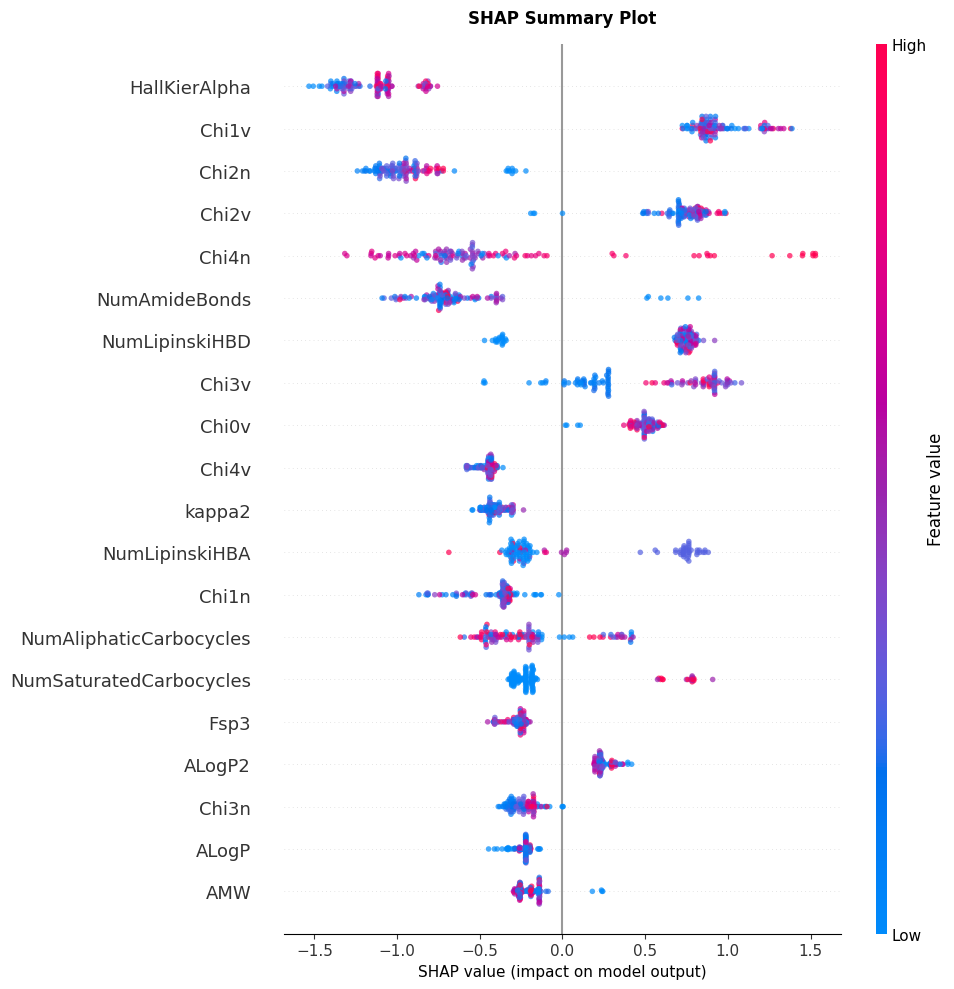

Plot tersimpa


In [48]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===== Nama fitur physicochemical (56 kolom) =====
feature_names = [
'logP','LabuteASA', 'TPSA', 'AMW', 'NumLipinskiHBA', 'NumLipinskiHBD',
'NumRotatableBonds', 'NumHBD', 'NumHBA', 'NumAmideBonds',
'NumHeteroAtoms', 'NumAtoms', 'NumRings', 'NumAromaticRings',
'NumSaturatedRings', 'NumAliphaticRings', 'NumAromaticHeterocycles',
'NumSaturatedHeterocycles', 'NumAliphaticHeterocycles',
'NumAromaticCarbocycles', 'NumSaturatedCarbocycles',
'NumAliphaticCarbocycles', 'FractionCSP3', 'Chi0v', 'Chi1v', 'Chi2v',
'Chi3v', 'Chi4v', 'Chi1n', 'Chi2n', 'Chi3n', 'Chi4n', 'HallKierAlpha',
'kappa1', 'kappa2', 'kappa3', 'ALogP', 'ALogP2', 'AMR', 'MLogP',
'nAtomP', 'bpol', 'nB', 'nHBAcc',
'nHBDon', 'nAtomLAC', 'nAtomLC', 'PetitjeanNumber', 'nRotB',
'LipinskiFailures', 'TopoPSA', 'VAdjMat', 'XLogP', 'Fsp3',
'Molecular weight', 'fragC'

]

# ===== Buat DataFrame dengan nama kolom =====
X_phys = pd.DataFrame(x_test_rdkit_cdk, columns=feature_names)

# ===== Hitung SHAP values RF (paksa main effect only) =====
print("Menghitung SHAP values xgb...")
explainer_xgb = shap.TreeExplainer(xgb_p)

# Gunakan model_output="probability" dan paksa main effect saja
shap_values_xgb = explainer_xgb(X_phys)  # versi baru SHAP API

# Cek shape
print(f"Shape shap_values_xgb.values: {shap_values_xgb.values.shape}")

# Kalau 3D (n_samples, n_features, n_classes) — ambil class 1
if len(shap_values_xgb.values.shape) == 3:
    shap_vals = shap_values_xgb.values[:, :, 1]
    print(f"Diambil class 1, shape final: {shap_vals.shape}")
else:
    shap_vals = shap_values_xgb.values
    print(f"Shape final: {shap_vals.shape}")

# ===== Summary Plot (Beeswarm persis seperti gambar referensi) =====
plt.figure(figsize=(10, 10))
shap.summary_plot(
    shap_vals,
    X_phys,
    feature_names=feature_names,
    plot_type="dot",
    max_display=20,
    show=False,
    alpha=0.7,       # transparansi titik supaya tidak terlalu padat
    plot_size=None   # biarkan SHAP atur ukuran sendiri
)
plt.title("SHAP Summary Plot", 
          fontsize=12, fontweight='bold', pad=15)
plt.xlabel("SHAP value (impact on model output)", fontsize=11)
plt.tight_layout()
plt.savefig("shap_Dermal_XGB.png", dpi=300, bbox_inches='tight')
plt.show()
print("Plot tersimpa")

Menghitung SHAP values XGB...
Shape shap_values_xgb.values: (126, 56)
Shape final: (126, 56)


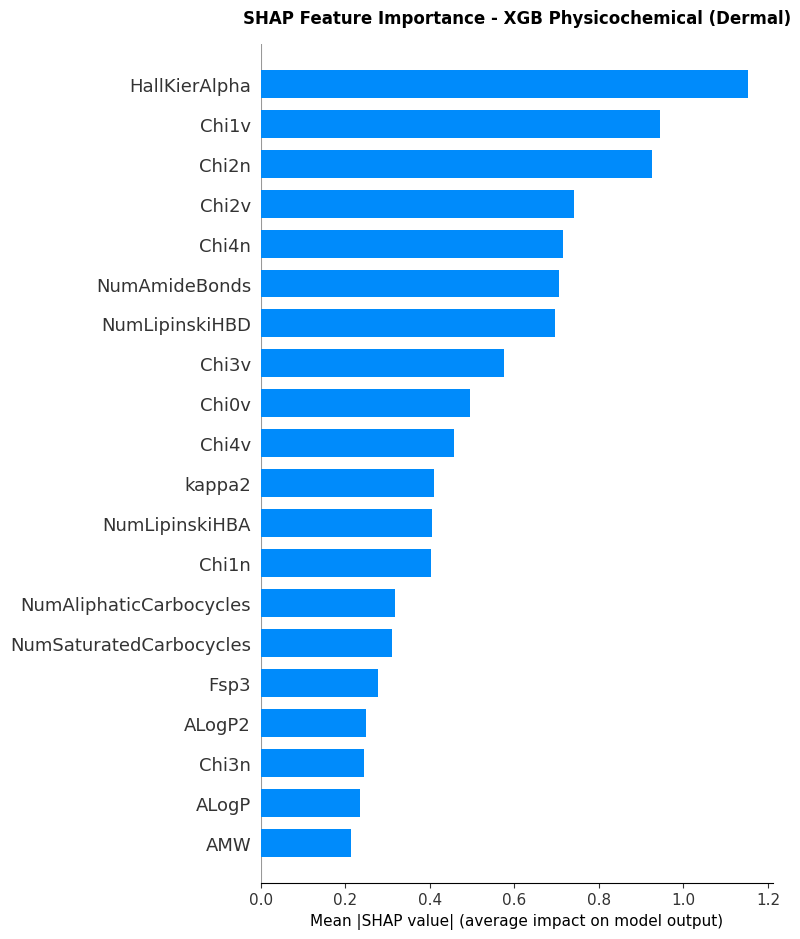

Plot tersimpan: shap_Dermal_XGB_bar.png


In [49]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

feature_names = [
'logP','LabuteASA', 'TPSA', 'AMW', 'NumLipinskiHBA', 'NumLipinskiHBD',
'NumRotatableBonds', 'NumHBD', 'NumHBA', 'NumAmideBonds',
'NumHeteroAtoms', 'NumAtoms', 'NumRings', 'NumAromaticRings',
'NumSaturatedRings', 'NumAliphaticRings', 'NumAromaticHeterocycles',
'NumSaturatedHeterocycles', 'NumAliphaticHeterocycles',
'NumAromaticCarbocycles', 'NumSaturatedCarbocycles',
'NumAliphaticCarbocycles', 'FractionCSP3', 'Chi0v', 'Chi1v', 'Chi2v',
'Chi3v', 'Chi4v', 'Chi1n', 'Chi2n', 'Chi3n', 'Chi4n', 'HallKierAlpha',
'kappa1', 'kappa2', 'kappa3', 'ALogP', 'ALogP2', 'AMR', 'MLogP',
'nAtomP', 'bpol', 'nB', 'nHBAcc',
'nHBDon', 'nAtomLAC', 'nAtomLC', 'PetitjeanNumber', 'nRotB',
'LipinskiFailures', 'TopoPSA', 'VAdjMat', 'XLogP', 'Fsp3',
'Molecular weight', 'fragC'
]

X_phys = pd.DataFrame(
    np.array(x_test_rdkit_cdk, dtype=np.float64),
    columns=feature_names
)

print("Menghitung SHAP values XGB...")
explainer_xgb = shap.TreeExplainer(xgb_p)
shap_values_xgb = explainer_xgb(X_phys)

print(f"Shape shap_values_xgb.values: {shap_values_xgb.values.shape}")

if len(shap_values_xgb.values.shape) == 3:
    shap_vals = shap_values_xgb.values[:, :, 1]
    print(f"Diambil class 1, shape final: {shap_vals.shape}")
else:
    shap_vals = shap_values_xgb.values
    print(f"Shape final: {shap_vals.shape}")

# ===== Bar Chart =====
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_vals,
    X_phys,
    feature_names=feature_names,
    plot_type="bar",       # <-- ganti ke bar
    max_display=20,
    show=False,
)
plt.title("SHAP Feature Importance - XGB Physicochemical (Dermal)",
          fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Mean |SHAP value| (average impact on model output)", fontsize=11)
plt.tight_layout()
plt.savefig("shap_Dermal_XGB_bar.png", dpi=300, bbox_inches='tight')
plt.show()
print("Plot tersimpan: shap_Dermal_XGB_bar.png")